(2, 4)
final cost 0.0002735272137423888
theta [8.02332063 8.55704618] b -7.701387374091878


<function matplotlib.pyplot.show(close=None, block=None)>

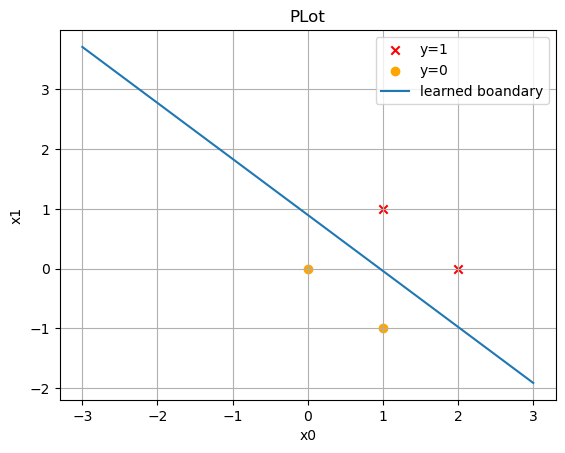

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Gamma hat is functional margin 
#gamma is a geomertirc margin
# Want to choose w,b to maximise geometric margin


#Defining intial 
#x = np.array([[-1,1],[1,1],[-1,-1],[1,-1]])
#x = np.array([[-1,2],[1,2],[-1,0],[1,0]])
x = np.array([[1,1],[2,0],[0,0],[1,-1]])
x = x.T
print(x.shape)
y = np.array([1,1,0,0])

#Our parameters
theta = np.array([0.2,-0.1])
b = -10
alpha = 1

#Def sig
def sig(z):
    #We want to clip th input so we dont go overflow errors
    z = np.clip(z,-500,500)
    res = 1/(1+np.e**(-z))
    return res

#definight h as pred
def pred(x, theta, b):
    #print(theta)
    #print(x)
    #print(b)
    ans = theta @ x + b
    #print(ans)
    res = sig(ans)
    return res

#Theta
def update(x,y,h,theta,b):
    m = len(y)
    l = len(theta)
    grad_theta = np.zeros(l)
    for i in range(l):
        grad_theta[i] = (1/m)*np.sum((h-y)* x[i,:])
        theta[i] = theta[i] - alpha * grad_theta[i]
    grad_beta = (1/m) * np.sum(h-y)
    b = b - alpha * grad_beta
    return theta, b

def cost(x,y,h):
    m = len(y)
    res = -(1/m) * np.sum(y*np.log(h)+(1-y)*np.log(1-h))
    return res


def iteration(x,y,theta,b,num):    
    for j in range(num):
        h = pred(x,theta,b)
        cos = cost(x, y, h)
        theta, b = update(x, y, h, theta,b)
        #print('iteration',j+1,'theta',theta,'b',b)
        #print('cost is', cos)
    print('final cost', cos)
    return theta, b

xp = np.linspace(-3,3,100)
theta, b = iteration(x,y,theta,b,10000)
print('theta', theta,'b',b)
yp = -(1/theta[1])*(b+theta[0]*xp)

dec = y >0.5 #We use dec to turn y into true or false statemtn

x_y = x.T[dec]
x_y = x_y.T

x_n = x.T[~dec]
x_n = x_n.T
#print(x_y)
#print(x_n)
#We use there varaible x_n and x_y to seperate between these two varaibles

#print('theta',theta,'b',b)

plt.scatter(x_y[0,:], x_y[1,:], marker="x", color="red", label='y=1')
plt.scatter(x_n[0,:], x_n[1,:], marker="o", color="orange", label='y=0')
plt.plot(xp, yp, label='learned boandary')
#plt.xlim(-2, 2)
#plt.ylim(-1,3)
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('PLot')
plt.grid(True)
plt.legend()


plt.show



In [71]:
# movinf to 3 dimenions to see if it works
x = np.array([[1,1,1],[2,0,1],[0,0,0],[1,-1,0]])
x = x.T

y = np.array([1,1,0,0])


theta = np.array([0.1,0.1,0.1])
b = 0
alpha = 2
m = len(y)


#xp = np.linspace(-3,3,100)
theta, b = iteration(x,y,theta,b,10)
print('theta', theta,'b',b)
#yp = -(1/theta[1])*(b+theta[0]*xp)

#This works fine

final cost 0.12036129167537693
theta [1.15237764 1.94654597 1.5494618 ] b -1.4360730283016163


In [73]:
#Now i will import a real data to try use
#We will try classify breast cancer malignant or benign
#Initially i only use first 5 entries
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

x = data.data
y = data.target

print(x.shape) #There are 569 instances
x=x.T   #We correct shape to make it equal


print(x[:,200:205].shape)

print(y.shape) 
print(y[200:205])

x = x[:,200:205]
y = y[200:205]
print(x) #x here is very samll and sometimes very big usually e**1 or e**0


l = len(x)  #l here is our number of dimensions or unmber of parametrs were using
print(l)

theta = np.zeros(l)

b = 0

alpha = 1

theta, b = iteration(x,y,theta,b,10)
#print('theta', theta,'b',b)



(569, 30)
(30, 5)
(569,)
[1 0 0 0 1]
[[1.223e+01 1.754e+01 2.329e+01 1.381e+01 1.247e+01]
 [1.956e+01 1.932e+01 2.667e+01 2.375e+01 1.860e+01]
 [7.854e+01 1.151e+02 1.589e+02 9.156e+01 8.109e+01]
 [4.610e+02 9.516e+02 1.685e+03 5.978e+02 4.819e+02]
 [9.586e-02 8.968e-02 1.141e-01 1.323e-01 9.965e-02]
 [8.087e-02 1.198e-01 2.084e-01 1.768e-01 1.058e-01]
 [4.187e-02 1.036e-01 3.523e-01 1.558e-01 8.005e-02]
 [4.107e-02 7.488e-02 1.620e-01 9.176e-02 3.821e-02]
 [1.979e-01 1.506e-01 2.200e-01 2.251e-01 1.925e-01]
 [6.013e-02 5.491e-02 6.229e-02 7.421e-02 6.373e-02]
 [3.534e-01 3.971e-01 5.539e-01 5.648e-01 3.961e-01]
 [1.326e+00 8.282e-01 1.560e+00 1.930e+00 1.044e+00]
 [2.308e+00 3.088e+00 4.667e+00 3.909e+00 2.497e+00]
 [2.724e+01 4.073e+01 8.316e+01 5.272e+01 3.029e+01]
 [7.514e-03 6.090e-03 9.327e-03 8.824e-03 6.953e-03]
 [1.779e-02 2.569e-02 5.121e-02 3.108e-02 1.911e-02]
 [1.401e-02 2.713e-02 8.958e-02 3.112e-02 2.701e-02]
 [1.140e-02 1.345e-02 2.465e-02 1.291e-02 1.037e-02]
 [1.503e-

C:\Users\berti\AppData\Local\Temp\ipykernel_39152\404401558.py:54: RuntimeWarning: divide by zero encountered in log
  res = -(1/m) * np.sum(y*np.log(h)+(1-y)*np.log(1-h))
C:\Users\berti\AppData\Local\Temp\ipykernel_39152\404401558.py:54: RuntimeWarning: invalid value encountered in multiply
  res = -(1/m) * np.sum(y*np.log(h)+(1-y)*np.log(1-h))


In [68]:
hat = [0,10000,-2000,4]
hat = np.clip(hat, -500, 500)
print(hat)
print(sig(hat))

[   0  500 -500    4]
[5.00000000e-001 1.00000000e+000 7.12457641e-218 9.82013790e-001]
